# Analisis Integral de la Dinamica Monetaria y Cambiaria de Argentina
### Un Estudio Intertemporal del Impacto de las Politicas de Estabilizacion y la Deuda (2016-2017 vs. 2024-2025)

#### 1. Introduccion y Justificacion del Estudio
La macroeconomia argentina contemporanea se caracteriza por la recurrencia de desequilibrios estructurales y cambios drasticos en los regimenes de politica monetaria y cambiaria. A menudo, las estrategias diseñadas para contener la nominalidad y estabilizar el sistema financiero conllevan severas implicancias en la distribucion del ingreso y en el endeudamiento de la nacion.

Este estudio realiza un contraste analitico y empirico entre dos esquemas monetarios opuestos aplicados en la ultima decada:
- **La gestion 2016-2017:** Caracterizada por la desregulacion cambiaria inicial, el regimen de metas de inflacion mediante altas tasas reales de interes, y una fuerte expansion del endeudamiento externo internacional que desemboco en la crisis de 2018 y el subsecuente programa de asistencia Stand-By con el Fondo Monetario Internacional (FMI).
- **La gestion 2024-2025:** Caracterizada por un programa de estabilizacion de shock sustentado en superavit fiscal financiero, crawling peg al 2% mensual, emision cero de la base monetaria, y la licuacion de los pasivos del Banco Central y de los ingresos de la poblacion mediante tasas de interes reales negativas.

A traves de la unificacion y procesamiento de datos provistos por el Banco Central (BCRA), la Comision Nacional de Valores (CNV) y la Bolsa y Mercados Argentinos (BYMA), analizaremos de que manera las politicas monetarias de ambos periodos impactaron sobre el ahorro en moneda local (depositos), el mercado corporativo de capitales (Obligaciones Negociables) y, centralmente, sobre el poder adquisitivo real de los saldos monetarios de la poblacion.

> **Nota sobre esta entrega.** Este cuaderno retoma y completa el trabajo iniciado en la pre-entrega. A las etapas de exploracion, limpieza, feature engineering y EDA ya presentadas se les suman ahora las etapas de modelado: definicion del problema de aprendizaje automatico, entrenamiento y comparacion de modelos, evaluacion con metricas, validacion cruzada, interpretacion de errores y conclusiones. Durante la revision para la entrega final se corrigieron ademas dos cuestiones metodologicas de la version previa, que se documentan en las secciones 5.3 y 7.

## 2. Contexto Macroeconomico e Institucional

Para comprender la dinamica de las series temporales, es indispensable caracterizar los marcos conceptuales de ambas politicas economicas y la continuidad de sus principales actores tecnicos:

### 2.1 El Regimen de Metas de Inflacion (2016-2017)
Bajo la direccion del Banco Central conducido por Federico Sturzenegger y la posterior gestion de Luis Caputo en el Ministerio de Finanzas, la administracion implemento un esquema de metas de inflacion con flotacion cambiaria. La politica monetaria operaba elevando la tasa nominal de interes (LEBAC) en terminos reales para desalentar la demanda agregada y esterilizar la emision. Este enfoque de la **Escuela Monetarista** asumia que la inflacion es un fenomeno estrictamente monetario controlable mediante el precio del dinero. Sin embargo, la persistencia del deficit fiscal y la acumulacion de pasivos de corto plazo en el Banco Central derivaron en una perdida de credibilidad, una masiva reversion de los flujos de capitales (sudden stop) en 2018 y la contratacion de un prestamo Stand-By historico con el FMI por USD 57.000 millones para evitar el default.

### 2.2 El Programa de Estabilizacion de Shock y Licuacion (2024-2025)
Nuevamente con la presencia de Luis Caputo (como Ministro de Economia) y Santiago Bausili (en la presidencia del Banco Central), la administracion de Javier Milei inicio un plan de estabilizacion enfocado en el ancla cambiaria (crawling peg al 2% mensual) y el saneamiento del balance del Banco Central mediante la emision de base monetaria cero. Metodologicamente, se recurrio a una profunda **licuacion de saldos reales**: las tasas de interes pasivas (BADLAR) se mantuvieron sistematicamente por debajo del ritmo de inflacion mensual de shock (tasas reales negativas). Este mecanismo licuo de forma acelerada los pasivos remunerados del Banco Central y licuo asimismo los ingresos y sueldos reales de la poblacion, traduciendose en una marcada desmonetizacion del consumo interno. Simultaneamente, la gestion se concentro en refinanciar y obtener rollover de la deuda contraida con el FMI en 2018.

In [1]:
# Importacion de librerias de procesamiento, visualizacion y analisis numerico
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Silenciamos advertencias no criticas para mantener limpia la salida del reporte
warnings.filterwarnings("ignore")

# Semilla global para reproducibilidad de los experimentos
RANDOM_STATE = 42

# Configuracion estetica de graficos para reportes macrofinancieros
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## 3. Carga y Consolidacion de Datos (Data Wrangling)

Procedemos a preparar el entorno y consolidar los archivos de las series temporales.

### 3.1 Deteccion de Entorno y Carga de Datasets (Soporte Google Colab)
Para asegurar la total portabilidad y ejecucion del cuaderno en entornos locales o en la nube de Google Colab, implementamos un cargador dinamico interactivo que intenta clonar automaticamente el repositorio de GitHub y ofrece una carga interactiva como fallback.

In [2]:
# Deteccion automatica de Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

datasets_dir = "datasets"

if IN_COLAB:
    print("--- Entorno Google Colab detectado ---")
    import os

    # Intentar clonar automaticamente los datasets desde el repositorio de GitHub del proyecto
    if not os.path.exists(datasets_dir):
        repo_name = "argentina-monetary-macro-analysis"
        try:
            print("Intentando clonar datasets de forma automatica desde el repositorio de GitHub...")
            os.system(f"git clone https://github.com/joaquinescalante/{repo_name}.git temp_repo")
            if os.path.exists("temp_repo/datasets"):
                os.rename("temp_repo/datasets", datasets_dir)
                print("Datasets clonados y organizados exitosamente en la carpeta 'datasets/'.")
            os.system("rm -rf temp_repo")
        except Exception as e:
            print("No se pudo clonar automaticamente el repositorio.")

    # Fallback: Carga interactiva si la clonacion automatica falla o no tiene los archivos
    if not os.path.exists(datasets_dir) or len(os.listdir(datasets_dir)) == 0:
        if not os.path.exists(datasets_dir):
            os.makedirs(datasets_dir)
        from google.colab import files
        print("Por favor, suba de forma manual los archivos CSV correspondientes a los datasets del proyecto:")
        uploaded = files.upload()

        # Reubicar los archivos cargados en el directorio local datasets/
        for filename in uploaded.keys():
            destino = os.path.join(datasets_dir, filename)
            if os.path.exists(destino):
                os.remove(destino)
            os.rename(filename, destino)
        print("\nDatasets cargados e interactivamente organizados en la carpeta 'datasets/'.")
else:
    print("--- Entorno local detectado. Los datasets se cargaran directamente desde la carpeta 'datasets/' ---")

--- Entorno local detectado. Los datasets se cargaran directamente desde la carpeta 'datasets/' ---


In [3]:
# Carga de archivos temporales mensuales consolidados
df_ipc = pd.read_csv(os.path.join(datasets_dir, "Indice IPC-IPCGA empalmado.csv"))
df_tasas = pd.read_csv(os.path.join(datasets_dir, "TASA BADLAR Y ADELANTOS.csv"))
df_dep_usd = pd.read_csv(os.path.join(datasets_dir, "volumen de deposito- USD.csv"))
df_dep_ars = pd.read_csv(os.path.join(datasets_dir, "volumen de depositos - ars.csv"))
df_byma = pd.read_csv(os.path.join(datasets_dir, "Volumen operado de mercado BYMa-IAMC.xlsx - Hoja2.csv"))
df_cpi_us = pd.read_csv(os.path.join(datasets_dir, "Consumer Price Index for All Urban Consumers (CPU-)EEUU - Hoja 1.csv"))

# Carga del registro de emisiones de ONs (Frecuencia diaria)
df_on = pd.read_csv(os.path.join(datasets_dir, "ON para base de datos.csv"))

print("Datasets cargados exitosamente en memoria.")

Datasets cargados exitosamente en memoria.


In [4]:
# Estandarizacion de formato de fecha en todos los DataFrames
dfs_mensuales = [df_ipc, df_tasas, df_dep_usd, df_dep_ars, df_byma, df_cpi_us]
for df in dfs_mensuales:
    df['fecha'] = pd.to_datetime(df['fecha'])

df_on['Fecha'] = pd.to_datetime(df_on['Fecha'])

# Consolidacion de las series mensuales mediante merge
df_macro = df_ipc.copy()
for df in dfs_mensuales[1:]:
    df_macro = pd.merge(df_macro, df, on='fecha', how='outer')

df_macro = df_macro.sort_values('fecha').reset_index(drop=True)
print(f"Dimensiones del DataFrame macroeconomico consolidado: {df_macro.shape}")

Dimensiones del DataFrame macroeconomico consolidado: (30, 26)


### 3.2 Inspeccion Inicial y Estadisticas del Dataset Consolidado
Exhibimos las primeras observaciones consolidadas del dataset macroeconomico y evaluamos sus estadisticas descriptivas principales.

In [5]:
# Visualizar las primeras 5 filas de las columnas mas relevantes
columnas_muestrario = ['fecha', 'Índice_Empalmado _(Dic-16=100)', 'Tasa_BADLAR_promedio_mensual_TNA', 'Saldo_Plazo_Fijo_PESOS_residente_miles_ARS', 'CPI']
df_macro[columnas_muestrario].head()

,fecha,Índice_Empalmado _(Dic-16=100),Tasa_BADLAR_promedio_mensual_TNA,Saldo_Plazo_Fijo_PESOS_residente_miles_ARS,CPI
0,2016-01-01,73.830215,0.2394,455219696.0,236.916
1,2016-02-01,76.760876,0.2375,452527533.0,237.111
2,2016-03-01,79.307915,0.2776,466341148.0,238.132
3,2016-04-01,84.498552,0.2835,467498947.0,239.261
4,2016-05-01,88.752316,0.2931,469134263.0,240.229


In [6]:
# Resumen estadistico descriptivo de las variables clave
df_macro[columnas_muestrario[1:]].describe().T

,count,mean,std,min,25%,50%,75%,max
Índice_Empalmado _(Dic-16=100),30.0,3.382184e+03,3.451041e+03,7.383021e+01,9.372244e+01,2.183824e+03,6.814475e+03,8.353316e+03
Tasa_BADLAR_promedio_mensual_TNA,30.0,3.648333e-01,2.341180e-01,1.900000e-01,2.379750e-01,2.889500e-01,3.626000e-01,1.068200e+00
Saldo_Plazo_Fijo_PESOS_residente_miles_ARS,30.0,1.476022e+10,1.577760e+10,4.525275e+08,4.999792e+08,7.650564e+09,2.740925e+10,4.255000e+10
CPI,30.0,2.777049e+02,3.773345e+01,2.369160e+02,2.411018e+02,2.761090e+02,3.147320e+02,3.197990e+02


## 4. Limpieza de Datos y Tratamiento de Outliers

Procedemos a identificar la existencia de duplicados y nulos. Asimismo, analizamos los valores extremos (outliers) macroeconomicos.

In [7]:
# 4.1 Verificacion y Tratamiento de Duplicados y Nulos
duplicados = df_macro.duplicated(subset=['fecha']).sum()
nulos_totales = df_macro.isnull().sum().sum()
print(f"Registros duplicados por fecha: {duplicados}")
print(f"Valores faltantes en el dataset consolidado: {nulos_totales}")

if nulos_totales > 0:
    # Interpolacion lineal con ffill y bfill para evitar nulos en extremos de la serie
    df_macro = df_macro.interpolate(method='linear').ffill().bfill()
    print("Imputacion lineal y propagacion de extremos realizada.")

Registros duplicados por fecha: 0
Valores faltantes en el dataset consolidado: 0


In [8]:
# 4.2 Analisis de Outliers en Variables Clave
variables_interes = ['Tasa_BADLAR_promedio_mensual_TNA', 'Saldo_Plazo_Fijo_PESOS_residente_miles_ARS']

for var in variables_interes:
    Q1 = df_macro[var].quantile(0.25)
    Q3 = df_macro[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_macro[(df_macro[var] < limite_inferior) | (df_macro[var] > limite_superior)]
    print(f"Outliers detectados en '{var}' (Linf: {limite_inferior:.2f}, Lsup: {limite_superior:.2f}): {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[['fecha', var]])

# Nota Metodologica: Los outliers identificados no obedecen a fallas de medicion sino a shocks macros y
# devaluaciones bruscas reales. En el contexto de la Economia Conductual, la presencia de estos saltos
# condiciona las expectativas no lineales de los agentes financieros. Mantener estos registros es crucial
# para entrenar estimadores en regimenes de alta volatilidad.

Outliers detectados en 'Tasa_BADLAR_promedio_mensual_TNA' (Linf: 0.05, Lsup: 0.55): 4
        fecha  Tasa_BADLAR_promedio_mensual_TNA
15 2024-01-01                            1.0682
16 2024-02-01                            1.0651
17 2024-03-01                            0.8520
18 2024-04-01                            0.6354
Outliers detectados en 'Saldo_Plazo_Fijo_PESOS_residente_miles_ARS' (Linf: -39863925094.38, Lsup: 67773153076.62): 0


## 5. Transformaciones de Datos y Feature Engineering

Para unificar y comparar los periodos de analisis, desarrollaremos las siguientes variables macroeconomicas derivadas:
1. **Identificacion del regimen (gestion):** etiqueta que distingue el periodo 2016-2017 del periodo 2024-2025. Se calcula primero porque varias transformaciones posteriores se computan de manera independiente dentro de cada regimen.
2. **Tipo de Cambio Implicito Mensual (TCI):** Estimado a partir del ratio entre la emision corporativa en Pesos y Dolares de Obligaciones Negociables. Desde la perspectiva de la **Escuela Austriaca**, este precio representa el canal libre de asignacion de capitales que eluden las restricciones cambiarias (cepo).
3. **Tasa de Inflacion Mensual de Argentina y EEUU:** Variacion porcentual mensual de los indices de precios correspondientes.
4. **Tasas de Interes Reales Efectivas Mensuales (TEM Real):** Deflactadas por la inflacion del periodo mediante la ecuacion de Fisher.
5. **Devaluacion mensual y grado de dolarizacion:** variables de comportamiento que resumen la presion cambiaria y la sustitucion de monedas.
6. **Agregacion y Deflactacion de Depositos:** Saldo total de depositos en pesos y dolares expresados en terminos reales de poder adquisitivo constante (base Diciembre 2016 = 100).

### 5.1 Identificacion del Periodo de Gestion
Etiquetamos cada observacion segun el regimen de politica economica al que pertenece. Definir esta variable en primer lugar es importante desde el punto de vista metodologico: como los dos periodos no son contiguos en el tiempo, las variaciones intermensuales (inflacion, devaluacion) deben calcularse **dentro de cada regimen** y no sobre la serie concatenada.

In [9]:
# 5.1 Identificacion del Periodo de Gestion
df_macro['gestion'] = np.where(df_macro['fecha'].dt.year <= 2017, 'Macri (2016-2017)', 'Milei (2024-2025)')
print(df_macro['gestion'].value_counts())

gestion
Macri (2016-2017)    15
Milei (2024-2025)    15
Name: count, dtype: int64


### 5.2 Estimacion del Tipo de Cambio Implicito Corporativo (ON)
Reconstruimos un tipo de cambio libre implicito a partir del cociente entre el monto emitido en pesos y el monto emitido en dolares de las Obligaciones Negociables corporativas, promediado por mes.

In [10]:
# 5.2 Estimacion del Tipo de Cambio Implicito Corporativo (ON)
df_on_usd = df_on[df_on['Moneda'].str.upper() == 'USD'].copy()
df_on_usd['TC_implicito'] = (df_on_usd['MONTO_ARS_EMISION_MILLONES'] * 1_000_000) / df_on_usd['Monto_emision']

# Agrupar por mes y calcular el promedio del tipo de cambio implicito corporativo
df_on_usd['fecha_mensual'] = df_on_usd['Fecha'].dt.to_period('M').dt.to_timestamp()
df_tc_mensual = df_on_usd.groupby('fecha_mensual')['TC_implicito'].mean().reset_index()
df_tc_mensual.rename(columns={'fecha_mensual': 'fecha', 'TC_implicito': 'tipo_cambio_implicito'}, inplace=True)

# Acoplar al DataFrame principal
df_macro = pd.merge(df_macro, df_tc_mensual, on='fecha', how='left')

# Imputacion robusta de meses sin emisiones mediante forward y backward fill
df_macro['tipo_cambio_implicito'] = df_macro['tipo_cambio_implicito'].ffill().bfill()
print("Tipo de cambio implicito de ONs acoplado e imputado.")

Tipo de cambio implicito de ONs acoplado e imputado.


### 5.3 Calculo de Tasas de Inflacion Mensual

Calculamos la variacion porcentual mensual de los indices de precios de Argentina (indice empalmado Dic-16 = 100) y de Estados Unidos (CPI).

**Correccion metodologica respecto de la pre-entrega.** En la version previa la inflacion se computaba con `pct_change()` sobre la serie completa ordenada por fecha. Dado que entre marzo de 2017 y enero de 2024 hay un salto de casi siete años sin datos, esa variacion generaba un valor espurio en el primer mes del segundo regimen (una "inflacion mensual" de miles por ciento) que contaminaba luego las tasas reales de todo el tramo 2024-2025. Para evitarlo, calculamos las variaciones de manera independiente **dentro de cada gestion** y completamos el primer mes de cada periodo con la mediana de su propio regimen.

In [11]:
# 5.3 Calculo de Tasas de Inflacion Mensual (por regimen, para evitar el salto entre periodos)
df_macro['inflacion_mensual_arg'] = df_macro.groupby('gestion')['Índice_Empalmado _(Dic-16=100)'].pct_change()
df_macro['inflacion_mensual_usa'] = df_macro.groupby('gestion')['CPI'].pct_change()

# El primer mes de cada gestion queda sin variacion; lo imputamos con la mediana intra-regimen
df_macro['inflacion_mensual_arg'] = df_macro['inflacion_mensual_arg'].fillna(
    df_macro.groupby('gestion')['inflacion_mensual_arg'].transform('median'))
df_macro['inflacion_mensual_usa'] = df_macro['inflacion_mensual_usa'].fillna(
    df_macro.groupby('gestion')['inflacion_mensual_usa'].transform('median'))

print("Inflacion mensual por gestion (min / media / max):")
print((df_macro.groupby('gestion')[['inflacion_mensual_arg']].agg(['min', 'mean', 'max']) * 100).round(2))

Inflacion mensual por gestion (min / media / max):
                  inflacion_mensual_arg             
                                    min  mean    max
gestion                                             
Macri (2016-2017)                 -0.76  2.62   6.54
Milei (2024-2025)                  2.21  4.90  13.24


### 5.4 Calculo de Tasas de Interes Reales (Ecuacion de Fisher)

Para deflactar las tasas de interes nominales (TNA), primero convertimos la TNA a una tasa efectiva mensual nominal ($TEM_{\text{nominal}} = TNA / 12$) y aplicamos la formula de Fisher para obtener la tasa efectiva mensual real ($TEM_{\text{real}}$):

$$1 + TEM_{\text{real}} = \frac{1 + TEM_{\text{nominal}}}{1 + \text{Inflación}_{\text{mensual}}}$$

Posteriormente, anualizamos la tasa real para que sea comparable con la TNA nominal de referencia:

$$TNA_{\text{real}} = TEM_{\text{real}} \times 12$$

**Canal de Transmision y Licuacion:** Las tasas nominales fijadas sistematicamente por debajo de la inflacion representan una transferencia real de riqueza desde los acreedores (ahorristas y asalariados tenedores de pesos) hacia el deudor principal (Banco Central y Tesoro Nacional), licuando el valor real de la riqueza liquida de los hogares.

In [12]:
# 5.4 Tasas reales por la ecuacion de Fisher
# Convertimos la TNA a tasa efectiva mensual nominal (TEM)
df_macro['TEM_BADLAR'] = df_macro['Tasa_BADLAR_promedio_mensual_TNA'] / 12
df_macro['TEM_Adelantos'] = df_macro['Tasa_Adelantos_Promedio_mensual_TNA'] / 12

# Ecuacion de Fisher
df_macro['TEM_BADLAR_Real'] = ((1 + df_macro['TEM_BADLAR']) / (1 + df_macro['inflacion_mensual_arg'])) - 1
df_macro['TEM_Adelantos_Real'] = ((1 + df_macro['TEM_Adelantos']) / (1 + df_macro['inflacion_mensual_arg'])) - 1

# Tasa anualizada real equivalente (TNA Real)
df_macro['TNA_BADLAR_Real'] = df_macro['TEM_BADLAR_Real'] * 12
df_macro['TNA_Adelantos_Real'] = df_macro['TEM_Adelantos_Real'] * 12
print("Tasas reales calculadas exitosamente.")
print((df_macro.groupby('gestion')[['TNA_BADLAR_Real']].agg(['min', 'mean', 'max'])).round(3))

Tasas reales calculadas exitosamente.
                  TNA_BADLAR_Real              
                              min   mean    max
gestion                                        
Macri (2016-2017)          -0.471 -0.075  0.334
Milei (2024-2025)          -0.463 -0.083  0.580


### 5.5 Deflactacion de Depositos a Pesos Constantes
Agregamos los saldos de depositos de residentes en pesos y en dolares y los llevamos a terminos reales: los pesos se deflactan por el indice empalmado (base Dic-2016) y los dolares se convierten a moneda fisica dividiendo por el tipo de cambio implicito.

In [13]:
# 5.5 Deflactacion de Depositos a Pesos Constantes
# Agrupacion de saldos nominales de depositos de residentes en ARS
df_macro['depositos_totales_ARS_nom'] = (
    df_macro['Saldo_Cta_Cte_PESOS_residentes_miles_ARS'] +
    df_macro['Saldo_Caja_Ahorro_PESOS_residentes_miles_ARS'] +
    df_macro['Saldo_Plazo_Fijo_PESOS_residente_miles_ARS']
)

# Deflactamos por el Indice Empalmado (Dic-16 = 100) para obtener pesos constantes de poder adquisitivo
df_macro['depositos_totales_ARS_real'] = (df_macro['depositos_totales_ARS_nom'] / df_macro['Índice_Empalmado _(Dic-16=100)']) * 100

# Agrupacion de saldos nominales de depositos de residentes en USD (Valuados en pesos)
df_macro['depositos_totales_USD_val_ARS'] = (
    df_macro['Saldo_Cta_Cte_USD_residente_miles_ARS'] +
    df_macro['Saldo_Caja_Ahorro_USD_residente_miles_ARS'] +
    df_macro['Saldo_Plazo_Fijo_USD_residente_miles_ARS']
)

# Convertimos a USD fisicos dividiendo por el tipo de cambio implicito
df_macro['depositos_totales_USD_real'] = df_macro['depositos_totales_USD_val_ARS'] / df_macro['tipo_cambio_implicito']
print("Saldos agregados de depositos deflactados calculados.")

Saldos agregados de depositos deflactados calculados.


### 5.6 Variables de Comportamiento: Devaluacion Mensual y Dolarizacion
Construimos dos indicadores que resumen la reaccion de los agentes frente al regimen monetario y que utilizaremos mas adelante como predictores:
- **Devaluacion mensual del tipo de cambio implicito** (variacion intra-regimen), como medida de presion cambiaria.
- **Grado de dolarizacion** de los depositos, es decir, la proporcion de los saldos valuados en dolares sobre el total de depositos de residentes.

In [14]:
# 5.6 Variables de comportamiento
# Devaluacion mensual del TC implicito, calculada dentro de cada regimen
df_macro['devaluacion_mensual'] = df_macro.groupby('gestion')['tipo_cambio_implicito'].pct_change()
df_macro['devaluacion_mensual'] = df_macro['devaluacion_mensual'].fillna(
    df_macro.groupby('gestion')['devaluacion_mensual'].transform('median'))

# Grado de dolarizacion de los depositos (participacion del USD valuado en ARS sobre el total)
df_macro['dolarizacion'] = (
    df_macro['depositos_totales_USD_val_ARS'] /
    (df_macro['depositos_totales_USD_val_ARS'] + df_macro['depositos_totales_ARS_nom'])
)

print("Variables de comportamiento generadas: devaluacion_mensual, dolarizacion.")
print(df_macro.groupby('gestion')[['devaluacion_mensual', 'dolarizacion']].mean().round(4))

Variables de comportamiento generadas: devaluacion_mensual, dolarizacion.
                   devaluacion_mensual  dolarizacion
gestion                                             
Macri (2016-2017)               0.0039        0.1852
Milei (2024-2025)               0.0335        0.2636


## 6. Analisis Exploratorio de Datos (EDA) Comparativo

Procedemos a graficar y contrastar las principales dinamicas monetarias y financieras de ambos periodos economicos, incorporando rotulos y comentarios explicativos.

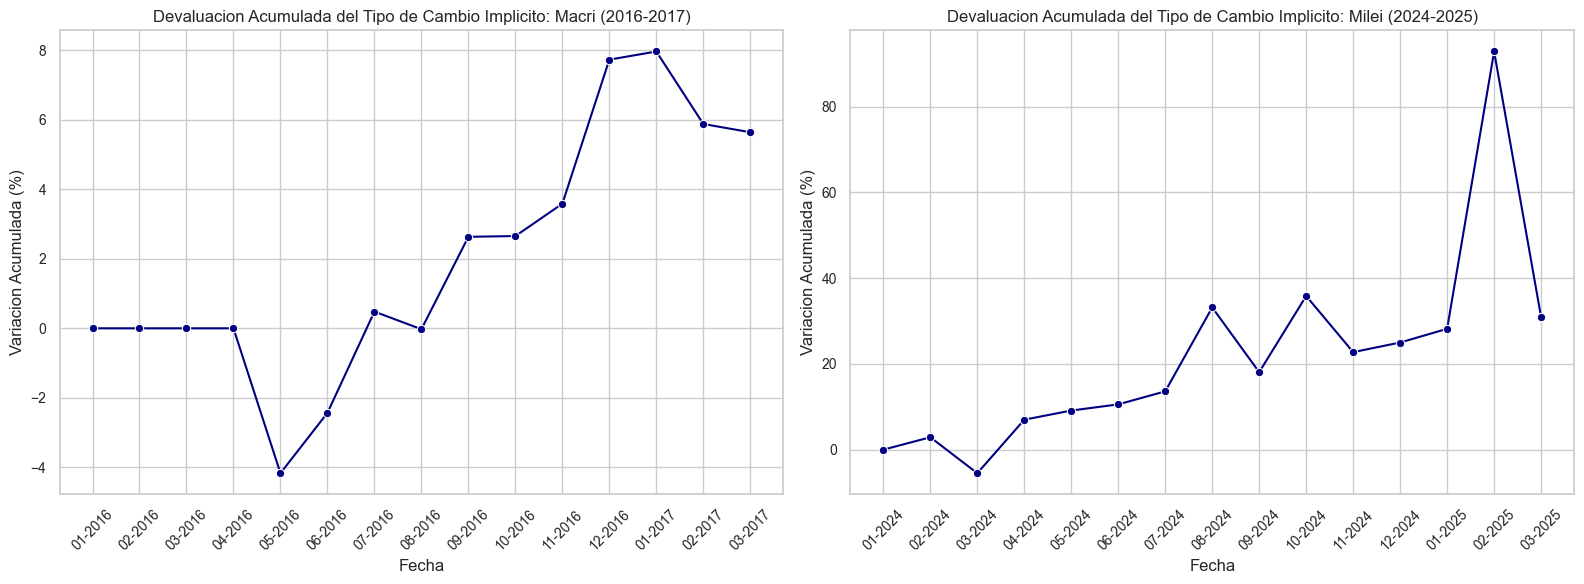

In [15]:
# 6.1 Evolucion del Tipo de Cambio Implicito y su Tasa de Devaluacion Mensual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (gest, data) in enumerate(df_macro.groupby('gestion')):
    ax = axes[i]
    # Normalizamos el tipo de cambio al inicio de cada periodo para observar la devaluacion acumulada relativa
    tc_inicial = data['tipo_cambio_implicito'].iloc[0]
    tc_normalizado = (data['tipo_cambio_implicito'] / tc_inicial - 1) * 100

    sns.lineplot(x=data['fecha'].dt.strftime('%m-%Y'), y=tc_normalizado, ax=ax, marker='o', color='navy')
    ax.set_title(f"Devaluacion Acumulada del Tipo de Cambio Implicito: {gest}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Variacion Acumulada (%)")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

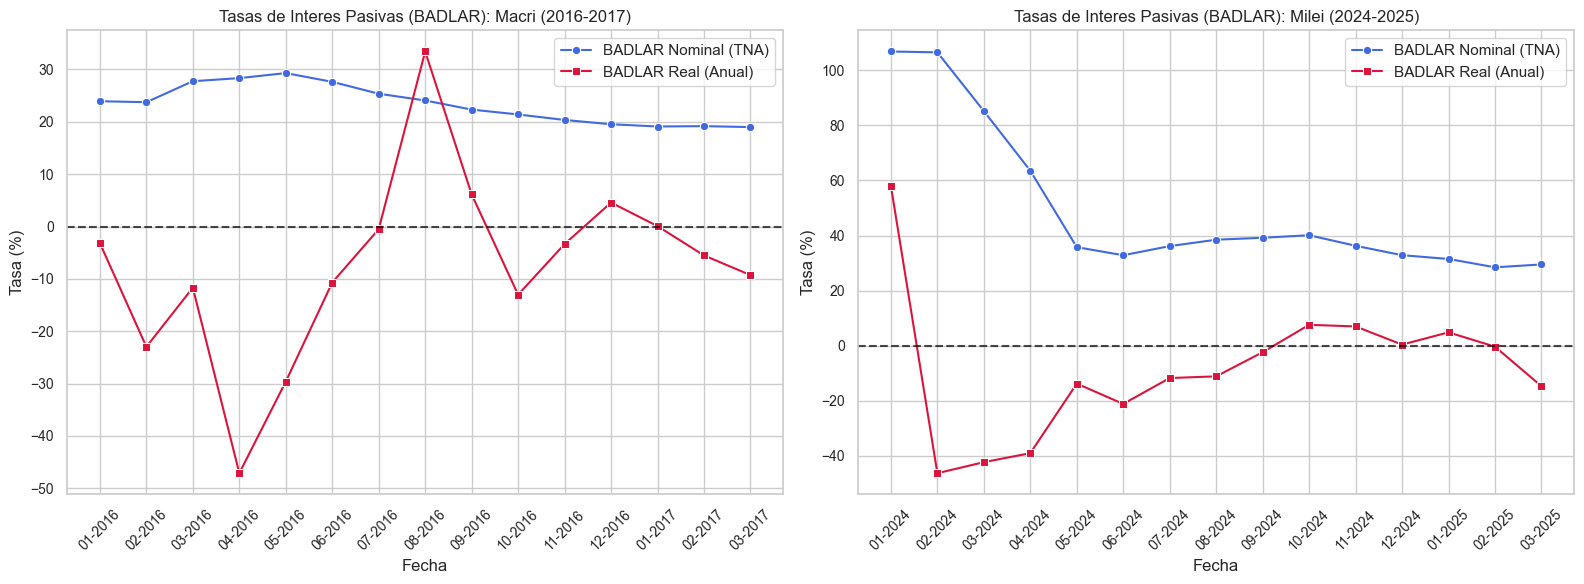

In [16]:
# 6.2 Tasas de Interes Nominales vs Reales (BADLAR)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (gest, data) in enumerate(df_macro.groupby('gestion')):
    ax = axes[i]
    # TNA nominal vs TNA real anualizada
    sns.lineplot(x=data['fecha'].dt.strftime('%m-%Y'), y=data['Tasa_BADLAR_promedio_mensual_TNA']*100,
                 ax=ax, marker='o', label='BADLAR Nominal (TNA)', color='royalblue')
    sns.lineplot(x=data['fecha'].dt.strftime('%m-%Y'), y=data['TNA_BADLAR_Real']*100,
                 ax=ax, marker='s', label='BADLAR Real (Anual)', color='crimson')

    ax.axhline(0, color='black', linestyle='--', alpha=0.7)
    ax.set_title(f"Tasas de Interes Pasivas (BADLAR): {gest}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Tasa (%)")
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

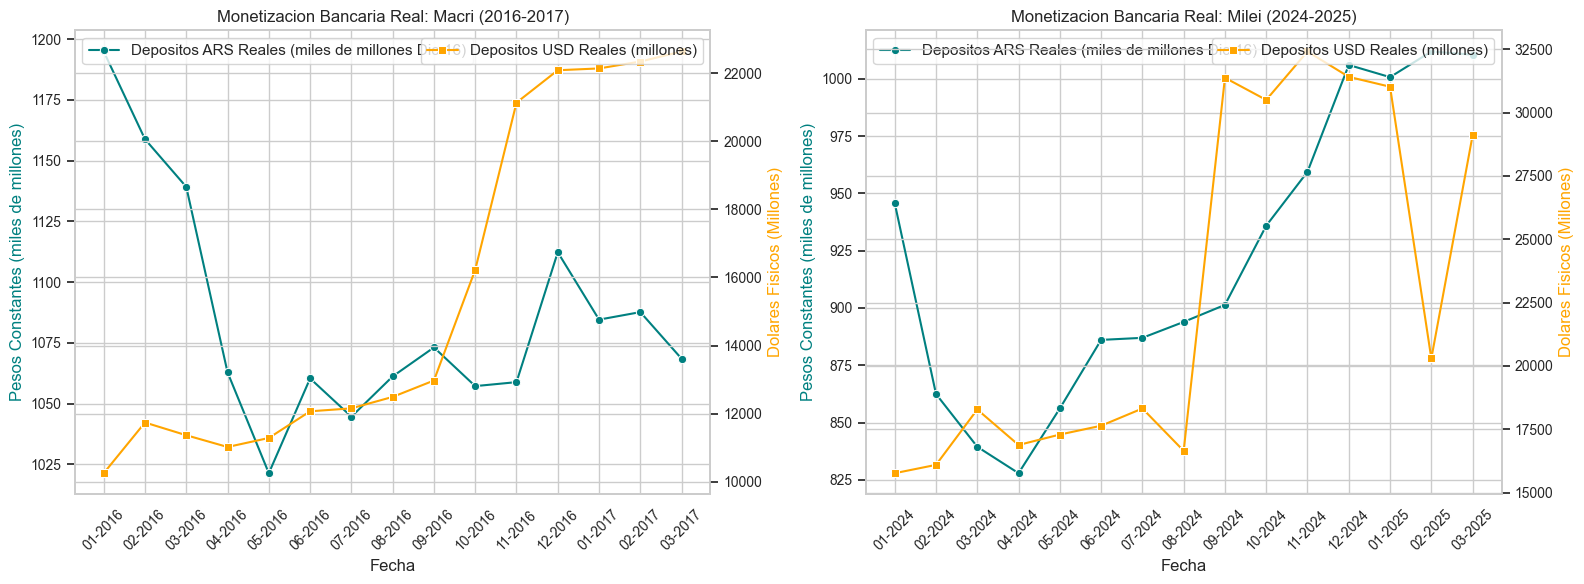

In [17]:
# 6.3 Evolucion Real de los Depositos del Sistema Financiero
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (gest, data) in enumerate(df_macro.groupby('gestion')):
    ax = axes[i]
    ax2 = ax.twinx()

    sns.lineplot(x=data['fecha'].dt.strftime('%m-%Y'), y=data['depositos_totales_ARS_real']/1e6,
                 ax=ax, marker='o', color='teal', label='Depositos ARS Reales (miles de millones Dic-16)')
    sns.lineplot(x=data['fecha'].dt.strftime('%m-%Y'), y=data['depositos_totales_USD_real']/1e3,
                 ax=ax2, marker='s', color='orange', label='Depositos USD Reales (millones)')

    ax.set_title(f"Monetizacion Bancaria Real: {gest}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Pesos Constantes (miles de millones)", color='teal')
    ax2.set_ylabel("Dolares Fisicos (Millones)", color='orange')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

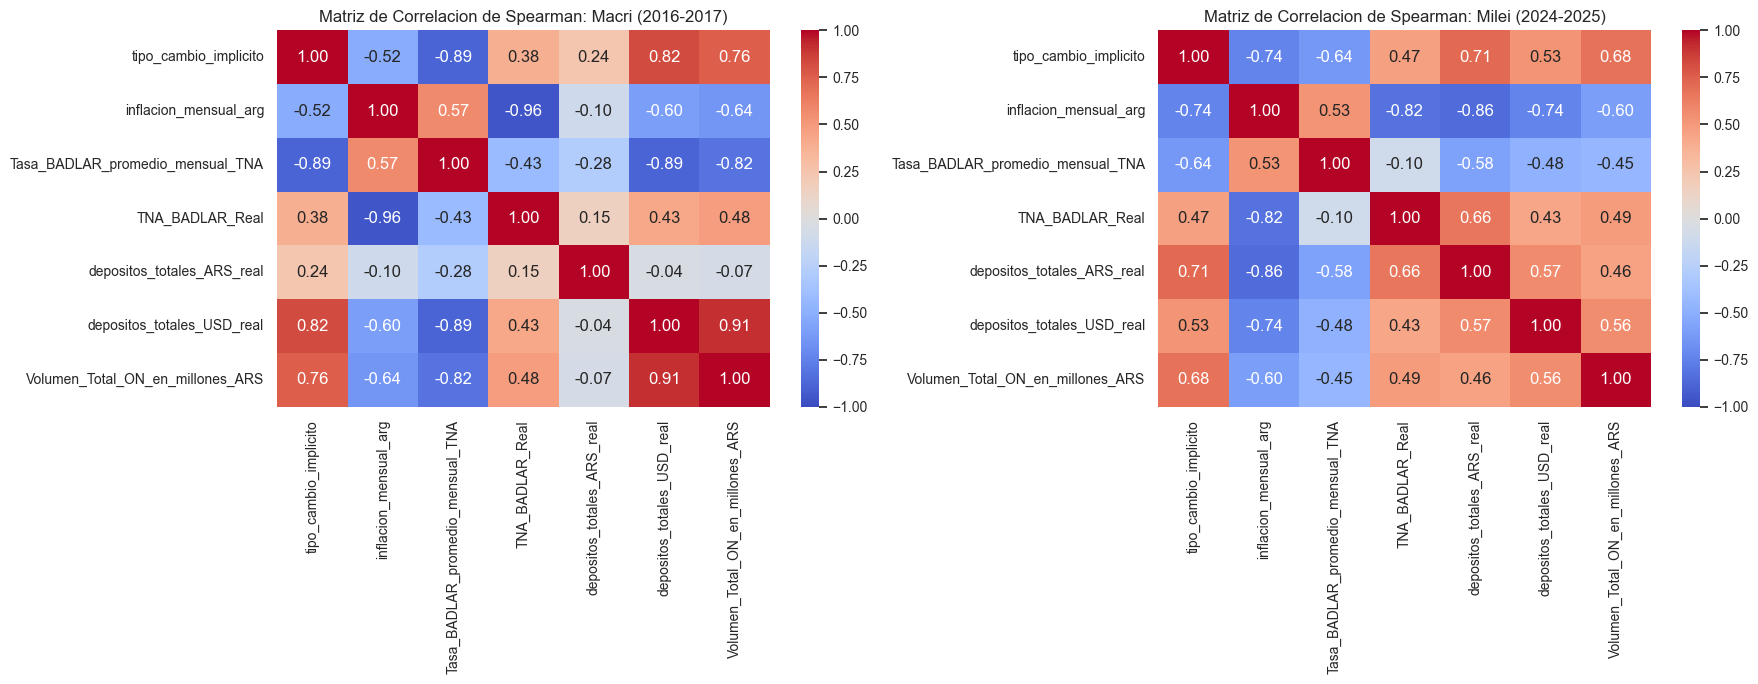

In [18]:
# 6.4 Matriz de Correlacion Cruzada de Spearman
variables_corr = [
    'tipo_cambio_implicito', 'inflacion_mensual_arg',
    'Tasa_BADLAR_promedio_mensual_TNA', 'TNA_BADLAR_Real',
    'depositos_totales_ARS_real', 'depositos_totales_USD_real',
    'Volumen_Total_ON_en_millones_ARS'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (gest, data) in enumerate(df_macro.groupby('gestion')):
    corr_matrix = data[variables_corr].corr(method='spearman')
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[i], vmin=-1, vmax=1)
    axes[i].set_title(f"Matriz de Correlacion de Spearman: {gest}")

plt.tight_layout()
plt.show()

## 7. Definicion de los Problemas de Machine Learning

Con el dataset consolidado y las variables derivadas, planteamos **dos problemas complementarios** que permiten poner a prueba, desde el aprendizaje automatico, la hipotesis central del estudio: que el comportamiento del ahorro y del sistema financiero responde a las condiciones monetarias de cada regimen.

- **Problema de regresion (Seccion 8):** estimar el nivel de ahorro real en pesos de los residentes (depositos totales en pesos a valores constantes) en funcion de las condiciones monetarias y cambiarias del mes. Como la variable objetivo es continua, corresponde un enfoque de **regresion**.
- **Problema de clasificacion (Seccion 9):** identificar si un mes se encuentra bajo un **regimen de licuacion** (tasa de interes real negativa) a partir de la huella de comportamiento de los ahorristas y del mercado de capitales. Como la variable objetivo es categorica binaria, corresponde un enfoque de **clasificacion**.

**Correccion de la pre-entrega respecto del target.** En la version previa se habia planteado predecir la tasa real `TNA_BADLAR_Real` a partir de un conjunto de variables que incluia la tasa nominal y la inflacion. Ese planteo incurria en una **fuga de informacion (data leakage)**: la tasa real es, por construccion, una funcion deterministica (ecuacion de Fisher) de la tasa nominal y la inflacion, de modo que el problema era circular y trivial (la correlacion entre el target y la inflacion superaba 0.99 en valor absoluto). En esta entrega redefinimos los targets hacia preguntas economicas genuinas y cuidamos, en cada modelo, que los predictores no determinen mecanicamente la variable a predecir.

**Nota sobre la particion y el tamaño muestral.** El dataset consta de 30 observaciones mensuales correspondientes a dos ventanas no contiguas (15 meses de 2016-2017 y 15 de 2024-2025). Se trata de un volumen acotado, por lo que priorizamos la **validacion cruzada** como estimador robusto del desempeño y complementamos con la evaluacion sobre un conjunto de test estratificado por gestion. Los resultados deben leerse como una prueba de concepto sobre datos limitados, no como un modelo productivo de pronostico.

## 8. Modelo de Regresion: Determinantes del Ahorro Real en Pesos

### 8.1 Seleccion y justificacion de los modelos
El objetivo es explicar el saldo real de depositos en pesos de los residentes (`depositos_totales_ARS_real`), una variable continua. Comparamos tres estimadores de complejidad creciente, lo que permite discutir el compromiso entre interpretabilidad y capacidad de ajuste:

- **Regresion Lineal**, como modelo base interpretable, que asume una relacion lineal entre las condiciones monetarias y el ahorro real.
- **Regresion Ridge**, que agrega regularizacion L2 para atenuar la colinealidad entre las variables macro (tasa real, inflacion y devaluacion covarian fuertemente dentro de cada regimen).
- **Random Forest**, un ensamble de arboles capaz de capturar relaciones no lineales y efectos de umbral, plausibles en un sistema con saltos de regimen.

Como predictores utilizamos un conjunto de variables monetarias y cambiarias economicamente motivadas por la teoria de la demanda de dinero, evitando incluir simultaneamente una variable y sus componentes:

- `TNA_BADLAR_Real`: rendimiento real del ahorro en pesos (incentivo a mantener saldos).
- `inflacion_mensual_arg`: erosion del poder adquisitivo (costo de oportunidad de la liquidez).
- `devaluacion_mensual`: presion de sustitucion hacia el dolar.
- `inflacion_mensual_usa`: condiciones externas.
- `Volumen_Total_ON_en_millones_ARS`: nivel de actividad del mercado de capitales.

In [19]:
# 8.2 Definicion de variables, particion y target
features_reg = [
    'TNA_BADLAR_Real', 'inflacion_mensual_arg', 'devaluacion_mensual',
    'inflacion_mensual_usa', 'Volumen_Total_ON_en_millones_ARS'
]
target_reg = 'depositos_totales_ARS_real'

# Expresamos el target en miles de millones de ARS constantes (Dic-2016) para facilitar la lectura
X_reg = df_macro[features_reg].copy()
y_reg = df_macro[target_reg] / 1e6

# Particion 80/20 estratificada por gestion, para que ambos regimenes esten representados en test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=df_macro['gestion'])

print(f"Observaciones totales: {len(X_reg)}")
print(f"Entrenamiento: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}")
print(f"Target: {target_reg} (en miles de millones de ARS constantes, base Dic-2016)")

Observaciones totales: 30
Entrenamiento: 24  |  Test: 6
Target: depositos_totales_ARS_real (en miles de millones de ARS constantes, base Dic-2016)


### 8.3 Entrenamiento y evaluacion sobre el conjunto de test
Entrenamos los tres modelos sobre el conjunto de entrenamiento y los evaluamos sobre el conjunto de test con las metricas apropiadas para regresion: **MAE** (error absoluto medio), **RMSE** (raiz del error cuadratico medio) y **R²** (coeficiente de determinacion). Los modelos lineales se encapsulan en un `Pipeline` con estandarizacion, de modo que el escalado se ajusta unicamente con los datos de entrenamiento y no filtra informacion del test.

In [20]:
# 8.3 Entrenamiento y evaluacion en test
modelos_reg = {
    'Regresion Lineal': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge (L2)': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
}

filas = []
predicciones = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    predicciones[nombre] = pred
    filas.append({
        'Modelo': nombre,
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': root_mean_squared_error(y_te, pred),
        'R2': r2_score(y_te, pred)
    })

tabla_test = pd.DataFrame(filas).set_index('Modelo').round(3)
print("Desempeño sobre el conjunto de TEST (target en miles de millones de ARS constantes):")
tabla_test

Desempeño sobre el conjunto de TEST (target en miles de millones de ARS constantes):


,MAE,RMSE,R2
Modelo,,,
Regresion Lineal,32.860,36.084,0.842
Ridge (L2),32.480,35.174,0.850
Random Forest,35.465,50.461,0.692


### 8.4 Validacion cruzada (K-Fold)
Dado el reducido numero de observaciones, un unico corte de test es una estimacion inestable del desempeño. Aplicamos **validacion cruzada de 5 particiones (K-Fold)** sobre el total de los datos para obtener una estimacion mas robusta, reportando la media y el desvio de cada metrica.

In [21]:
# 8.4 Validacion cruzada K-Fold (5 particiones)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas_cv = []
for nombre, modelo in modelos_reg.items():
    r2 = cross_val_score(modelo, X_reg, y_reg, cv=kf, scoring='r2')
    mae = -cross_val_score(modelo, X_reg, y_reg, cv=kf, scoring='neg_mean_absolute_error')
    rmse = -cross_val_score(modelo, X_reg, y_reg, cv=kf, scoring='neg_root_mean_squared_error')
    filas_cv.append({
        'Modelo': nombre,
        'R2 (media)': r2.mean(), 'R2 (desvio)': r2.std(),
        'MAE (media)': mae.mean(), 'RMSE (media)': rmse.mean()
    })

tabla_cv = pd.DataFrame(filas_cv).set_index('Modelo').round(3)
print("Validacion cruzada 5-Fold sobre el total del dataset:")
tabla_cv

Validacion cruzada 5-Fold sobre el total del dataset:


,R2 (media),R2 (desvio),MAE (media),RMSE (media)
Modelo,,,,
Regresion Lineal,0.403,0.325,56.039,65.339
Ridge (L2),0.427,0.305,53.592,63.977
Random Forest,0.645,0.133,40.414,51.707


La validacion cruzada modifica el ordenamiento que sugeria el unico corte de test. En ese corte puntual los modelos lineales lucen incluso mejores que el ensamble, pero se trata de una particion de apenas seis observaciones y, por lo tanto, muy sensible al azar. Al promediar cinco particiones distintas, el **Random Forest** pasa a ser claramente el modelo mas robusto (mayor R² medio y menor desvio), mientras que la Regresion Lineal y Ridge caen a un R² sensiblemente menor. Esta discrepancia entre el test y la validacion cruzada es, en si misma, el argumento para no confiar en un unico corte con tan pocos datos. La brecha entre el ajuste lineal promedio y el del ensamble indica ademas que la relacion entre las condiciones monetarias y el ahorro real no es estrictamente lineal, sino que involucra umbrales e interacciones (por ejemplo, el efecto de la tasa real depende del nivel de inflacion vigente).

### 8.5 Visualizacion de resultados e interpretacion de errores
Analizamos el modelo mas robusto en validacion cruzada (Random Forest) contrastando valores predichos frente a observados y examinando la distribucion de los residuos. Un modelo bien calibrado deberia alinear los puntos sobre la diagonal y presentar residuos sin estructura evidente.

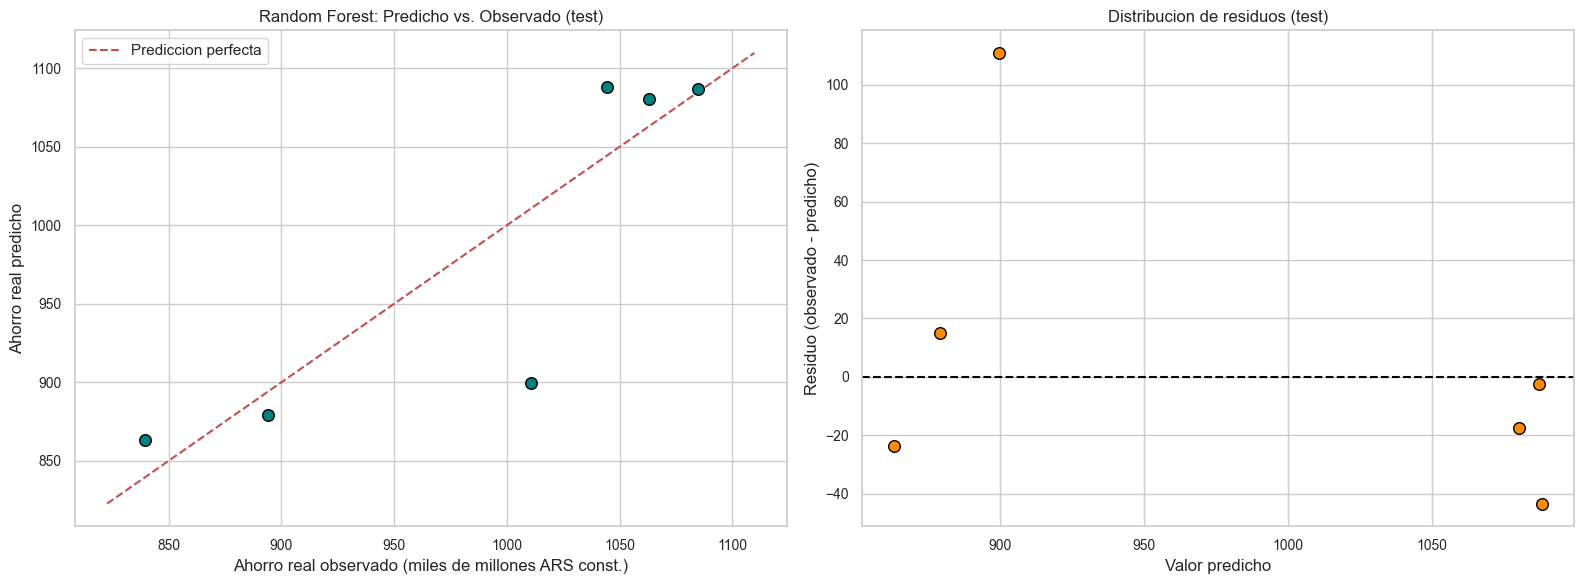

Residuo medio: 6.46  |  Desvio de los residuos: 50.05 (miles de millones ARS const.)


In [22]:
# 8.5 Predicho vs. Observado y analisis de residuos (Random Forest)
mejor_modelo = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_tr, y_tr)
pred_te = mejor_modelo.predict(X_te)
residuos = y_te.values - pred_te

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicho vs Observado
axes[0].scatter(y_te, pred_te, color='teal', s=70, edgecolor='black', zorder=3)
lims = [min(y_te.min(), pred_te.min()) * 0.98, max(y_te.max(), pred_te.max()) * 1.02]
axes[0].plot(lims, lims, 'r--', label='Prediccion perfecta')
axes[0].set_xlabel("Ahorro real observado (miles de millones ARS const.)")
axes[0].set_ylabel("Ahorro real predicho")
axes[0].set_title("Random Forest: Predicho vs. Observado (test)")
axes[0].legend()

# Residuos
axes[1].scatter(pred_te, residuos, color='darkorange', s=70, edgecolor='black', zorder=3)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel("Valor predicho")
axes[1].set_ylabel("Residuo (observado - predicho)")
axes[1].set_title("Distribucion de residuos (test)")

plt.tight_layout()
plt.show()

print(f"Residuo medio: {residuos.mean():.2f}  |  Desvio de los residuos: {residuos.std():.2f} (miles de millones ARS const.)")

### 8.6 Importancia de las variables e interpretacion economica
Comparamos que variables pesan mas en cada enfoque: la importancia por reduccion de impureza en el Random Forest y la magnitud de los coeficientes estandarizados en la Regresion Lineal.

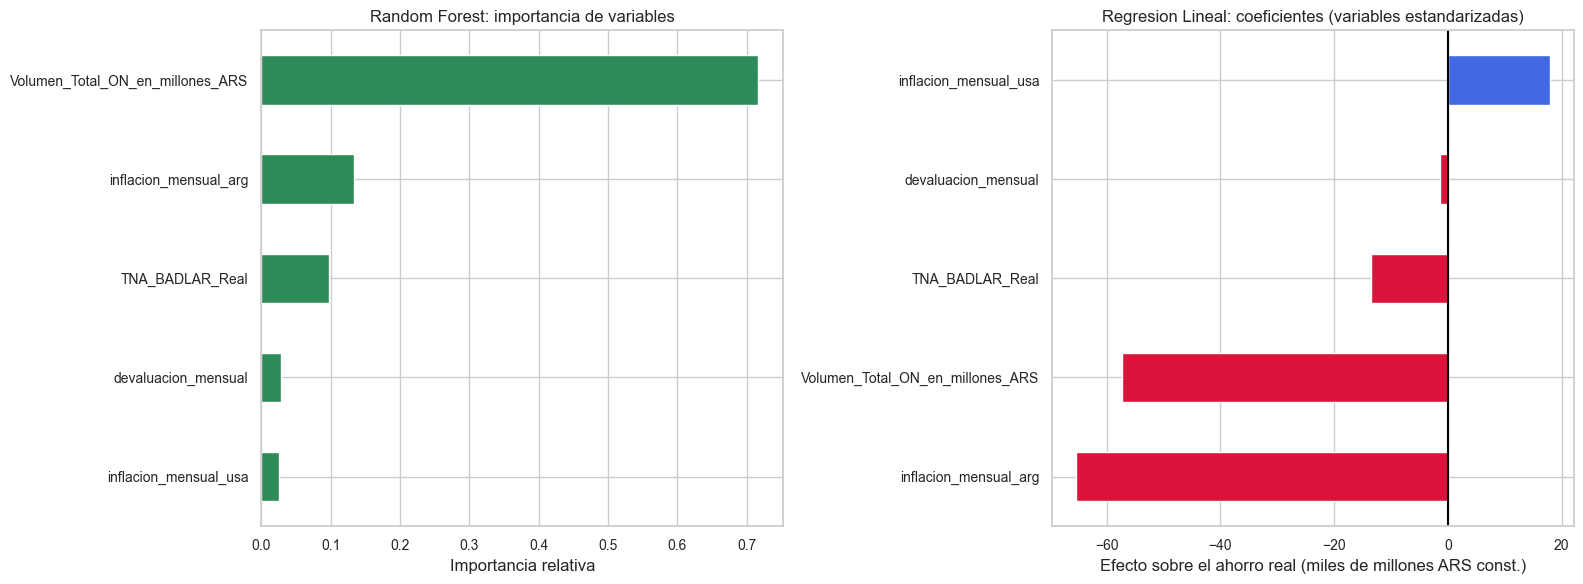

Importancia RF:
 Volumen_Total_ON_en_millones_ARS    0.717
inflacion_mensual_arg               0.134
TNA_BADLAR_Real                     0.097
devaluacion_mensual                 0.028
inflacion_mensual_usa               0.025

Coeficientes Lineales:
 inflacion_mensual_arg              -65.33
Volumen_Total_ON_en_millones_ARS   -57.35
TNA_BADLAR_Real                    -13.52
devaluacion_mensual                 -1.39
inflacion_mensual_usa               17.98


In [23]:
# 8.6 Importancia de variables (RF) y coeficientes estandarizados (Lineal)
imp_rf = pd.Series(mejor_modelo.feature_importances_, index=features_reg).sort_values()

modelo_lin = make_pipeline(StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
coef_lin = pd.Series(modelo_lin.named_steps['linearregression'].coef_, index=features_reg).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
imp_rf.plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title("Random Forest: importancia de variables")
axes[0].set_xlabel("Importancia relativa")

colores = ['crimson' if v < 0 else 'royalblue' for v in coef_lin.values]
coef_lin.plot(kind='barh', ax=axes[1], color=colores)
axes[1].axvline(0, color='black')
axes[1].set_title("Regresion Lineal: coeficientes (variables estandarizadas)")
axes[1].set_xlabel("Efecto sobre el ahorro real (miles de millones ARS const.)")

plt.tight_layout()
plt.show()

print("Importancia RF:\n", imp_rf.sort_values(ascending=False).round(3).to_string())
print("\nCoeficientes Lineales:\n", coef_lin.round(2).to_string())

**Lectura economica.** Las variables asociadas al nivel de actividad del mercado de capitales (volumen de ONs) y a la inflacion concentran la mayor parte del poder explicativo del ahorro real en pesos, mientras que la tasa real y la devaluacion aportan de forma mas marginal en estas dos ventanas. El signo negativo que la regresion lineal asigna a la inflacion es consistente con la teoria: a mayor inflacion, menor demanda real de saldos en pesos (la gente se desprende de liquidez que pierde valor). Es importante remarcar una limitacion interpretativa: dado que en ambos regimenes la tasa real fue mayormente negativa, su variabilidad util para explicar el ahorro es baja, y por eso su importancia individual resulta menor de lo que la narrativa haria esperar. Esto no contradice la hipotesis del trabajo, sino que la matiza: mas que el nivel puntual de la tasa real, es el conjunto de condiciones monetarias (inflacion y actividad financiera) el que ordena el comportamiento del ahorro.

## 9. Modelo de Clasificacion: Deteccion del Regimen de Licuacion

### 9.1 Definicion del target y prevencion de fuga de informacion
Definimos la variable objetivo `licuacion` como un indicador binario que vale **1 cuando la tasa de interes real (BADLAR deflactada por Fisher) es negativa** y 0 en caso contrario. Un mes de licuacion es aquel en que el ahorrista en pesos pierde poder adquisitivo aun colocando su dinero a plazo, el mecanismo central de transferencia de riqueza descripto en la Seccion 2.

**Punto metodologico central (prevencion de leakage).** La etiqueta se construye a partir de la tasa nominal y la inflacion. Por lo tanto, para evitar una fuga de informacion que volveria trivial el problema, **excluimos deliberadamente esas dos variables del conjunto de predictores**. El clasificador debe inferir el regimen unicamente a partir de la *huella de comportamiento* de los agentes: el nivel de depositos reales en pesos y dolares, el grado de dolarizacion, la devaluacion del tipo de cambio implicito, el volumen operado de ONs y la inflacion externa. La pregunta de investigacion es, entonces: **¿el comportamiento observable de los ahorristas y del mercado revela si estamos en un regimen de represion financiera?**

### 9.2 Justificacion de los modelos
Comparamos una **Regresion Logistica** (modelo lineal e interpretable, con `class_weight='balanced'` para compensar el desbalance de clases) y un **Random Forest** clasificador (capaz de capturar fronteras no lineales). Como las clases estan desbalanceadas, reportamos ademas de la exactitud (accuracy) las metricas de **precision, recall y F1-score**, y la **matriz de confusion**.

In [24]:
# 9.1 Construccion del target de clasificacion y de los predictores (sin leakage)
df_macro['licuacion'] = (df_macro['TNA_BADLAR_Real'] < 0).astype(int)

features_clf = [
    'depositos_totales_ARS_real', 'depositos_totales_USD_real', 'dolarizacion',
    'devaluacion_mensual', 'Volumen_Total_ON_en_millones_ARS', 'inflacion_mensual_usa'
]
X_clf = df_macro[features_clf].copy()
y_clf = df_macro['licuacion']

print("Distribucion de la clase 'licuacion' (1 = tasa real negativa):")
print(y_clf.value_counts().rename({0: 'No licuacion', 1: 'Licuacion'}))
print("\nDistribucion por gestion:")
print(pd.crosstab(df_macro['gestion'], df_macro['licuacion'].map({0: 'No licuacion', 1: 'Licuacion'})))

baseline = max(y_clf.mean(), 1 - y_clf.mean())
print(f"\nBaseline (clasificador que siempre predice la clase mayoritaria): {baseline:.3f}")

Distribucion de la clase 'licuacion' (1 = tasa real negativa):
licuacion
Licuacion       21
No licuacion     9
Name: count, dtype: int64

Distribucion por gestion:
licuacion          Licuacion  No licuacion
gestion                                   
Macri (2016-2017)         11             4
Milei (2024-2025)         10             5

Baseline (clasificador que siempre predice la clase mayoritaria): 0.700


In [25]:
# 9.2 Entrenamiento y evaluacion en test (estratificado por la clase)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf)

modelos_clf = {
    'Regresion Logistica': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
}

filas_clf = []
for nombre, modelo in modelos_clf.items():
    modelo.fit(X_tr_c, y_tr_c)
    pred = modelo.predict(X_te_c)
    filas_clf.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_te_c, pred),
        'Precision': precision_score(y_te_c, pred, zero_division=0),
        'Recall': recall_score(y_te_c, pred, zero_division=0),
        'F1': f1_score(y_te_c, pred, zero_division=0)
    })

tabla_clf = pd.DataFrame(filas_clf).set_index('Modelo').round(3)
print("Desempeño sobre el conjunto de TEST:")
tabla_clf

Desempeño sobre el conjunto de TEST:


,Accuracy,Precision,Recall,F1
Modelo,,,,
Regresion Logistica,0.500,1.00,0.25,0.40
Random Forest,0.667,0.75,0.75,0.75


### 9.3 Validacion cruzada estratificada
Aplicamos **validacion cruzada estratificada de 5 particiones** (`StratifiedKFold`), que preserva la proporcion de clases en cada fold. Es la estrategia adecuada frente al desbalance y al tamaño reducido de la muestra.

In [26]:
# 9.3 Validacion cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas_cv_clf = []
for nombre, modelo in modelos_clf.items():
    acc = cross_val_score(modelo, X_clf, y_clf, cv=skf, scoring='accuracy')
    f1 = cross_val_score(modelo, X_clf, y_clf, cv=skf, scoring='f1')
    prec = cross_val_score(modelo, X_clf, y_clf, cv=skf, scoring='precision')
    rec = cross_val_score(modelo, X_clf, y_clf, cv=skf, scoring='recall')
    filas_cv_clf.append({
        'Modelo': nombre,
        'Accuracy': acc.mean(), 'Precision': prec.mean(),
        'Recall': rec.mean(), 'F1': f1.mean()
    })

tabla_cv_clf = pd.DataFrame(filas_cv_clf).set_index('Modelo').round(3)
print(f"Validacion cruzada estratificada 5-Fold (baseline mayoritario = {baseline:.3f}):")
tabla_cv_clf

Validacion cruzada estratificada 5-Fold (baseline mayoritario = 0.700):


,Accuracy,Precision,Recall,F1
Modelo,,,,
Regresion Logistica,0.700,0.817,0.7,0.732
Random Forest,0.733,0.757,0.9,0.821


### 9.4 Matriz de confusion e interpretacion
Construimos la matriz de confusion con las predicciones de validacion cruzada (`cross_val_predict`), que utilizan a cada observacion como test una vez, y examinamos la importancia de las variables de comportamiento en el Random Forest.

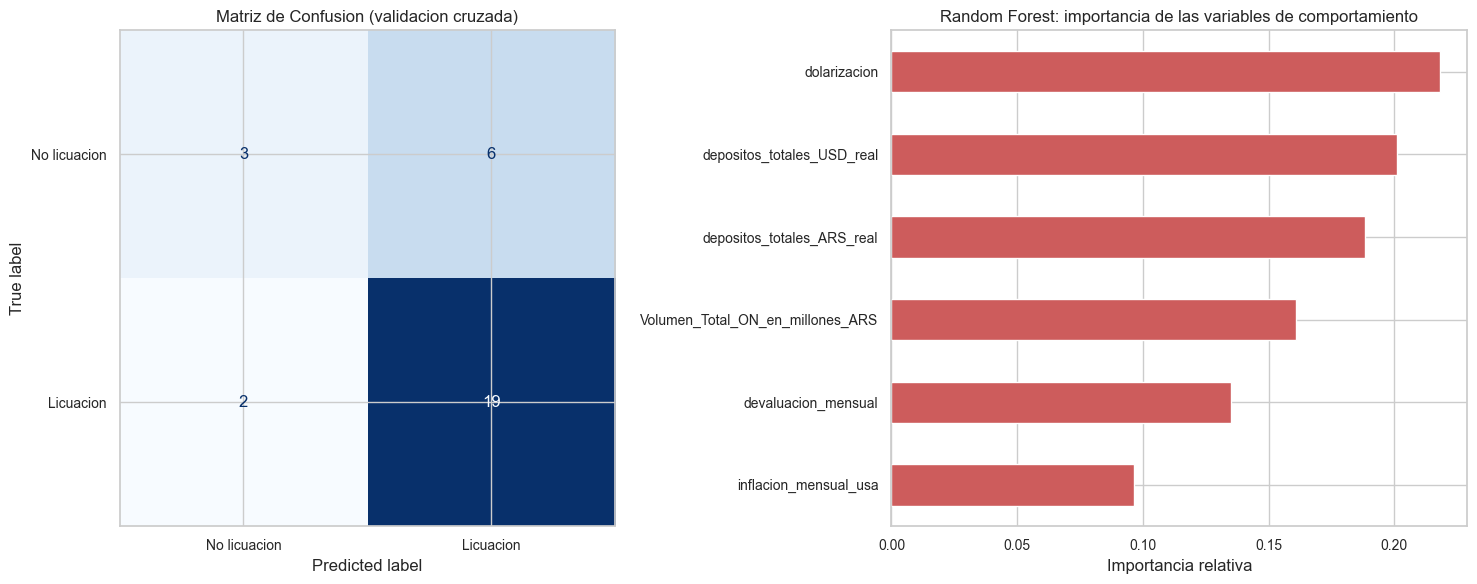

Reporte de clasificacion (validacion cruzada):

              precision    recall  f1-score   support

No licuacion       0.60      0.33      0.43         9
   Licuacion       0.76      0.90      0.83        21

    accuracy                           0.73        30
   macro avg       0.68      0.62      0.63        30
weighted avg       0.71      0.73      0.71        30



In [27]:
# 9.4 Matriz de confusion (validacion cruzada) e importancia de variables
clf_final = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
pred_cv = cross_val_predict(clf_final, X_clf, y_clf, cv=skf)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_clf, pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No licuacion', 'Licuacion'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Matriz de Confusion (validacion cruzada)")

clf_final.fit(X_clf, y_clf)
imp_clf = pd.Series(clf_final.feature_importances_, index=features_clf).sort_values()
imp_clf.plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title("Random Forest: importancia de las variables de comportamiento")
axes[1].set_xlabel("Importancia relativa")

plt.tight_layout()
plt.show()

print("Reporte de clasificacion (validacion cruzada):\n")
print(classification_report(y_clf, pred_cv, target_names=['No licuacion', 'Licuacion'], zero_division=0))

**Lectura de los resultados.** El Random Forest supera de forma modesta al baseline en exactitud (0.73 frente a 0.70), pero con una diferencia cualitativa que importa: a diferencia del clasificador trivial, que se limitaria a predecir siempre "licuacion" e ignoraria por completo la clase minoritaria, el modelo reparte sus predicciones entre ambas clases y recupera parte de los meses de tasa real positiva. Esto indica que la huella de comportamiento contiene señal genuina sobre el regimen de represion financiera, aun sin observar directamente la tasa ni la inflacion. La matriz de confusion muestra que el modelo detecta con alto recall los meses de licuacion (la clase mayoritaria) pero le cuesta mas identificar los de tasa real positiva: con tan pocos casos de la clase "No licuacion", tiende a subrepresentarla. En terminos de las variables, el grado de dolarizacion y los niveles de depositos reales aparecen entre las mas informativas, coherente con la idea de que la reaccion de los ahorristas (refugio en el dolar y caida del ahorro real en pesos) delata el contexto de tasas reales negativas. La lectura debe ser prudente: con 30 observaciones y clases desbalanceadas, el resultado es una prueba de concepto antes que un detector confiable.

## 10. Conclusiones y Observaciones Finales

El analisis comparativo e intertemporal de las dinamicas macrofinancieras de Argentina, complementado ahora con dos modelos de aprendizaje automatico, permite extraer las siguientes conclusiones.

**1. Sobre la hipotesis economica.** Los dos periodos analizados, pese a partir de diagnosticos ideologicamente opuestos (tasas reales fuertemente positivas en 2016-2017 versus tasas reales negativas y licuacion en 2024-2025), comparten un rasgo de fondo: el saneamiento monetario y cambiario de corto plazo se apoya sobre el ahorro real de la poblacion. En 2016-2017 el sostenimiento de saldos en pesos exigio un volumen insostenible de pasivos remunerados (LEBAC) y endeudamiento externo que desemboco en la asistencia del FMI de 2018; en 2024-2025 la estabilizacion se financio con una caida de los depositos reales y una licuacion del poder adquisitivo del ahorro minorista.

**2. Sobre el modelo de regresion.** El ahorro real en pesos resulta parcialmente explicable a partir de las condiciones monetarias del mes: el Random Forest alcanza un R² de validacion cruzada sensiblemente superior al del modelo lineal, lo que indica que la relacion es no lineal y esta mediada por umbrales de regimen. El poder explicativo se concentra en el nivel de actividad del mercado de capitales y la inflacion, mas que en la tasa real aislada, cuya variabilidad util es baja porque fue mayormente negativa en ambas ventanas.

**3. Sobre el modelo de clasificacion.** La huella de comportamiento de los ahorristas (dolarizacion, caida del ahorro real en pesos, presion cambiaria) permite identificar los meses de represion financiera por encima del azar, sin observar la tasa ni la inflacion. Esto respalda empiricamente la idea de que la licuacion deja una marca observable en las decisiones de cartera de la poblacion.

**4. Limitaciones.** La principal limitacion es el tamaño muestral: 30 observaciones mensuales sobre dos ventanas no contiguas. Esto restringe la complejidad de los modelos, vuelve inestables las estimaciones puntuales de test y obliga a apoyarse en la validacion cruzada. Ademas, al tratarse de series temporales, una particion aleatoria puede filtrar informacion entre meses vecinos; para un uso predictivo real seria mas apropiado un esquema de validacion que respete el orden temporal (por ejemplo `TimeSeriesSplit`).

**5. Posibilidades de mejora.** Ampliar la ventana temporal e incorporar meses intermedios, sumar variables rezagadas (lags) para capturar la dinamica de expectativas, incluir series de base monetaria, reservas y salarios reales, y adoptar validacion temporal estricta. Con mas datos seria viable explorar modelos de series de tiempo (SARIMAX) o de gradient boosting con regularizacion.

**6. Utilidad practica.** Mas alla del ejercicio academico, el enfoque muestra como variables de mercado de acceso publico (emisiones de ONs, depositos, tipo de cambio implicito) pueden combinarse para monitorear en que regimen monetario se encuentra la economia y como reacciona el ahorro de la poblacion, un insumo util para decisiones de cobertura y de politica.

## 11. Anexo

### 11.1 Datasets utilizados
Los datos originales se encuentran en la carpeta `datasets/` que acompaña a este cuaderno. Todas las series fueron llevadas a frecuencia mensual y consolidadas por fecha (las ONs, de frecuencia diaria, se agregaron por mes). Las ventanas cubiertas son enero 2016 - marzo 2017 y enero 2024 - marzo 2025.

| Archivo | Contenido | Fuente original |
|---|---|---|
| `Indice IPC-IPCGA empalmado.csv` | Indice de precios empalmado (base Dic-2016 = 100) | Elaboracion propia a partir del IPC (INDEC) e IPCBA (Direccion de Estadistica de la Ciudad de Buenos Aires) |
| `TASA BADLAR Y ADELANTOS.csv` | Tasas de interes BADLAR y Adelantos (TNA promedio mensual) | Banco Central de la Republica Argentina (BCRA) |
| `volumen de depositos - ars.csv` | Saldos de depositos en pesos por tipo y residencia | BCRA |
| `volumen de deposito- USD.csv` | Saldos de depositos en dolares por tipo y residencia | BCRA |
| `ON para base de datos.csv` | Registro de emisiones de Obligaciones Negociables (monto, moneda, TNA, plazo, sector) | Comision Nacional de Valores (CNV) |
| `Volumen operado de mercado BYMa-IAMC.xlsx - Hoja2.csv` | Volumen total operado de ONs | BYMA / Instituto Argentino de Mercado de Capitales (IAMC) |
| `Consumer Price Index for All Urban Consumers (CPU-)EEUU - Hoja 1.csv` | Indice de precios al consumidor de EEUU (CPI) | U.S. Bureau of Labor Statistics (BLS) |

### 11.2 Fuentes y referencias
- Banco Central de la Republica Argentina (BCRA) - Estadisticas monetarias y financieras: https://www.bcra.gob.ar/PublicacionesEstadisticas/Principales_variables.asp
- Comision Nacional de Valores (CNV): https://www.cnv.gov.ar/
- Bolsa y Mercados Argentinos (BYMA): https://www.byma.com.ar/ ; Instituto Argentino de Mercado de Capitales (IAMC): https://www.iamc.com.ar/
- Instituto Nacional de Estadistica y Censos (INDEC) - IPC: https://www.indec.gob.ar/
- Direccion General de Estadistica y Censos de la Ciudad de Buenos Aires (IPCBA): https://www.estadisticaciudad.gob.ar/
- U.S. Bureau of Labor Statistics - CPI: https://www.bls.gov/cpi/
- Ecuacion de Fisher para tasas reales; concepto de licuacion de pasivos y de represion financiera (marco teorico de referencia macroeconomica).

### 11.3 Aclaraciones metodologicas
- El tipo de cambio implicito se reconstruye a partir del cociente entre montos emitidos en pesos y en dolares de las ONs; es una aproximacion al tipo de cambio libre corporativo y no un dato de mercado directo.
- Las variaciones intermensuales (inflacion y devaluacion) se calculan de manera independiente dentro de cada gestion para no introducir el salto espurio que produciria el hueco temporal entre marzo de 2017 y enero de 2024.
- Se fija una semilla (`RANDOM_STATE = 42`) en todas las particiones y modelos para garantizar la reproducibilidad de los resultados.
- Dado el reducido numero de observaciones (30 meses), los resultados de los modelos deben interpretarse como una prueba de concepto y no como un sistema de pronostico productivo.